In [30]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as n
import matplotlib.pyplot as plt

In [31]:
set1 = pd.read_csv(
    "kunitz_set_1.txt",
    sep=r"\s+",
    header=None,
    names=["protein_id", "evalue", "true_label"]
)
set2 = pd.read_csv(
    "kunitz_set_2.txt",
    sep=r"\s+",
    header=None,
    names=["protein_id", "evalue", "true_label"]
)

set1.head()

# We create dataframes for the two sets and display the first few rows to verify that they have been loaded correctly.

,protein_id,evalue,true_label
0,sp|Q868Z9|PPN_DROME,5.300000e-17,1
1,sp|O76840|PPN1_CAEEL,4.200000e-19,1
2,sp|A0A6P8HC43|ATPI1_ACTTE,1.100000e-23,1
3,sp|Q28864|TFPI1_MACMU,5.700000e-27,1
4,sp|Q02445|TFPI1_RAT,3.200000e-25,1


In [32]:
print(set1.shape)
print(set2.shape)

print(set1["true_label"].value_counts())
print(set2["true_label"].value_counts())

# We check the shapes and the values to veryfy that the data has been loaded correctly

(287314, 3)
(287314, 3)
true_label
0    287115
1       199
Name: count, dtype: int64
true_label
0    287115
1       199
Name: count, dtype: int64


In [33]:
def calculate_counts(df, threshold):
    y_true = df["true_label"]
    y_pred = (df["evalue"] <= threshold).astype(int)

    tp = ((y_true == 1) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()

    return tp, fp, fn, tn

# We define a function to calculate the counts of TP, FP, FN, and TN for a given threshold.

In [34]:
calculate_counts(set1, 1e-5)
#test the function with a threshold of 1e-5 on set1 to verify that it works correctly.

(np.int64(199), np.int64(2), np.int64(0), np.int64(287113))

In [35]:
def calculate_metrics(df, threshold):
    tp, fp, fn, tn = calculate_counts(df, threshold)

    # True Positive Rate / Sensitivity / Recall:
    # among all real positives, how many did we correctly detect?
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    # False Positive Rate:
    # among all real negatives, how many did we incorrectly call positive?
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    # Accuracy:
    # among all proteins, how many did we classify correctly?
    accuracy = (tp + tn) / (tp + fp + fn + tn)

    return {
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "TPR": tpr,
        "FPR": fpr,
        "accuracy": accuracy
    }
# We define a function to calculate the metrics for a given threshold using the counts of TP, FP, FN, and TN.


In [36]:
calculate_metrics(set1, 1e-5)
# We test the function on set1 with a threshold of 1e-5 to verify that it works correctly.

{'threshold': 1e-05,
 'TP': np.int64(199),
 'FP': np.int64(2),
 'FN': np.int64(0),
 'TN': np.int64(287113),
 'TPR': np.float64(1.0),
 'FPR': np.float64(6.965849920763457e-06),
 'accuracy': np.float64(0.9999930389747802)}

In [37]:
# Generate several E-value thresholds.(logarithmically spaced from 10^-1 to 10^-15)
thresholds = [10 ** -i for i in np.arange(1, 15.1, 0.25)]

# Calculate metrics for each threshold for validation set 1.
set1_results = []

for threshold in thresholds:
    metrics = calculate_metrics(set1, threshold)
    set1_results.append(metrics)

set1_roc = pd.DataFrame(set1_results)
set1_roc.head()

,threshold,TP,FP,FN,TN,TPR,FPR,accuracy
0,0.100000,199,14,0,287101,1.0,0.000049,0.999951
1,0.056234,199,9,0,287106,1.0,0.000031,0.999969
2,0.031623,199,7,0,287108,1.0,0.000024,0.999976
3,0.017783,199,6,0,287109,1.0,0.000021,0.999979
4,0.010000,199,5,0,287110,1.0,0.000017,0.999983


In [38]:
# Calculate metrics for each threshold for validation set 2.
set2_results = []

for threshold in thresholds:
    metrics = calculate_metrics(set2, threshold)
    set2_results.append(metrics)


set2_roc = pd.DataFrame(set2_results)
set2_roc.head()

,threshold,TP,FP,FN,TN,TPR,FPR,accuracy
0,0.100000,198,18,1,287097,0.994975,0.000063,0.999934
1,0.056234,198,13,1,287102,0.994975,0.000045,0.999951
2,0.031623,198,9,1,287106,0.994975,0.000031,0.999965
3,0.017783,197,6,2,287109,0.989950,0.000021,0.999972
4,0.010000,197,6,2,287109,0.989950,0.000021,0.999972


In [39]:
# Combine validation set 1 and validation set 2 into one dataframe
combined = pd.concat([set1, set2], ignore_index=True)

# Check that the combined dataset has the expected size and labels
print(combined.shape)
print(combined["true_label"].value_counts())

(574628, 3)
true_label
0    574230
1       398
Name: count, dtype: int64


In [40]:
combined_results = []

for threshold in thresholds:
    metrics = calculate_metrics(combined, threshold)
    combined_results.append(metrics)

combined_roc = pd.DataFrame(combined_results)

combined_roc.head()

,threshold,TP,FP,FN,TN,TPR,FPR,accuracy
0,0.100000,397,32,1,574198,0.997487,0.000056,0.999943
1,0.056234,397,22,1,574208,0.997487,0.000038,0.999960
2,0.031623,397,16,1,574214,0.997487,0.000028,0.999970
3,0.017783,396,12,2,574218,0.994975,0.000021,0.999976
4,0.010000,396,11,2,574219,0.994975,0.000019,0.999977


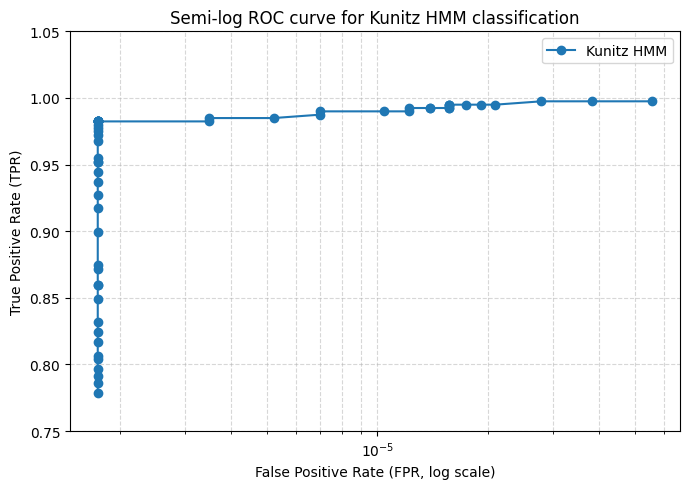

In [41]:
# Create a copy for plotting
combined_plot = combined_roc.copy()

# Log scale cannot display FPR = 0.
# Replace zero FPR values with a very small number only for plotting.
epsilon = 1e-8
combined_plot["FPR_log"] = combined_plot["FPR"].replace(0, epsilon)

# Plot combined semi-log ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    combined_plot["FPR_log"],
    combined_plot["TPR"],
    marker="o",
    label="Kunitz HMM"
)

plt.xscale("log")

plt.xlabel("False Positive Rate (FPR, log scale)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Semi-log ROC curve for Kunitz HMM classification")

plt.ylim(0.75, 1.05)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("kunitz_roc_curve_semilog_combined.png", dpi=300)
plt.show()

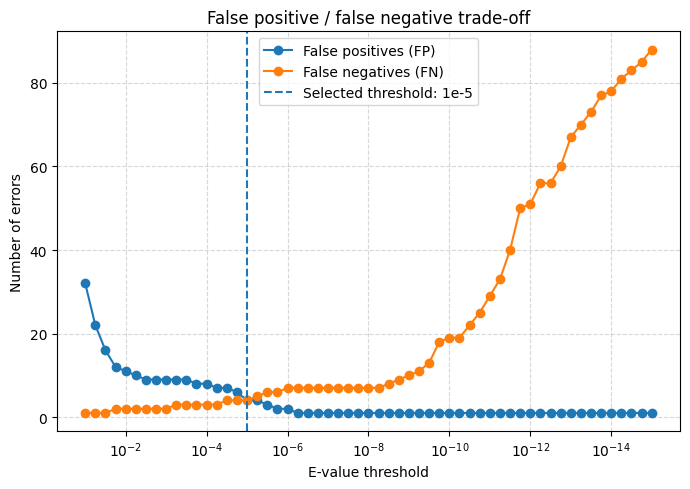

In [42]:
# Plot false positives and false negatives across thresholds.
# This helps visualize the trade-off between accepting weaker hits
# and missing true Kunitz proteins.

plt.figure(figsize=(7, 5))

plt.semilogx(combined_roc["threshold"], combined_roc["FP"], marker="o", label="False positives (FP)")
plt.semilogx(combined_roc["threshold"], combined_roc["FN"], marker="o", label="False negatives (FN)")

# Optional: mark selected threshold
plt.axvline(1e-5, linestyle="--", label="Selected threshold: 1e-5")

plt.gca().invert_xaxis()

plt.xlabel("E-value threshold")
plt.ylabel("Number of errors")
plt.title("False positive / false negative trade-off")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("kunitz_fp_fn_tradeoff.png", dpi=300)
plt.show()